In [2]:
pip install scikit-learn

  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------------------- -------------- 5.2/8.3 MB 27.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 23.8 MB/s  0:00:00
Using cached narwhals-2.25.0-py3-none-any.whl (467 kB)
   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   ---- ----------------------------------- 4.5/37.4 MB 21.4 MB/s eta 0:00:02
   --------- ------------------------------ 8.9/37.4 MB 21.0 MB/s eta 0:00:02
   -------------- ------------------------- 13.9/37.4 MB 22.0 MB/s eta 0:00:02
   -------------------- ------------------- 19.1/37.4 MB 22.4 MB/s eta 0:00:01
   -------------------------- ------------- 24.4/37.4 MB 22.6 MB/s eta 0:00:01
   ------------------------------ --------- 28.6/37.4 MB 22.3 MB/s eta 0:00:01
   ----------------------------------- ---- 33.3/

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')


In [4]:
df = pd.read_csv("leads_reales_clean.csv")
df.head(10)


,Año,Mes,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad
0,2024,Febrero,543,108,33,0,1,389,1,12,3.1,72
1,2024,Marzo,178,37,13,0,0,128,1,7,5.5,72
2,2024,Abril,416,79,46,3,0,288,1,8,2.8,69
3,2024,Mayo,422,33,100,17,0,274,5,13,4.7,65
4,2024,Junio,967,140,173,31,3,620,17,6,1.0,64
5,2024,Julio,954,112,251,12,9,570,5,21,3.7,60
6,2024,Agosto,1409,504,324,17,18,546,22,17,3.1,39
7,2024,Septiembre,1315,431,314,14,26,530,42,17,3.2,40
8,2024,Octubre,1973,514,606,18,13,822,72,23,2.8,42
9,2024,Noviembre,1562,153,321,44,4,1040,79,22,2.1,67


In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Año            28 non-null     int64  
 1   Mes            28 non-null     str    
 2   Total          28 non-null     int64  
 3   Ilocalizable   28 non-null     int64  
 4   No_Contesta    28 non-null     int64  
 5   D_Incorrectos  28 non-null     int64  
 6   Duplicados     28 non-null     int64  
 7   Efectivos      28 non-null     int64  
 8   Abiertos       28 non-null     int64  
 9   Ventas         28 non-null     int64  
 10  Conversion     28 non-null     float64
 11  Efectividad    28 non-null     int64  
dtypes: float64(1), int64(10), str(1)
memory usage: 2.8 KB


,Año,Total,Ilocalizable,No_Contesta,D_Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,2024.785714,1122.857143,143.178571,209.428571,19.107143,33.857143,660.142857,250.107143,26.964286,4.142857,61.642857
std,0.738223,421.939939,143.704185,153.734844,19.345474,32.244109,211.922018,236.059839,11.083796,1.249720,11.907714
min,2024.000000,178.000000,5.000000,13.000000,0.000000,0.000000,128.000000,1.000000,6.000000,1.000000,39.000000
25%,2024.000000,946.750000,44.250000,103.000000,3.000000,12.000000,564.000000,37.000000,19.250000,3.275000,52.750000
50%,2025.000000,1170.500000,110.000000,185.500000,13.000000,27.000000,704.500000,200.500000,30.000000,4.050000,64.000000
75%,2025.000000,1397.000000,154.250000,278.000000,31.750000,53.000000,738.000000,368.000000,36.250000,5.275000,70.000000
max,2026.000000,1973.000000,514.000000,606.000000,62.000000,136.000000,1040.000000,823.000000,41.000000,5.900000,83.000000


In [6]:
df.isnull().sum()

Año              0
Mes              0
Total            0
Ilocalizable     0
No_Contesta      0
D_Incorrectos    0
Duplicados       0
Efectivos        0
Abiertos         0
Ventas           0
Conversion       0
Efectividad      0
dtype: int64

Imputar los valores nulos de la columna “Año” con el numero del año correpondiente y convertir la columna a tipo numérico

In [ ]:
#ya se hizo ese proceso en la limpieza, lo único que añadi es asegurar que sean
#de tipo numérico

df['Año'] = df['Año'].astype(int)

Reemplazar los valores categóricos de la columna “Mes” con el numero del mes correpondiente y convertir la columna a tipo numérico

In [10]:
print(df.columns.tolist())

['Año', 'Mes', 'Total', 'Ilocalizable', 'No_Contesta', 'D_Incorrectos', 'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion', 'Efectividad']


In [16]:
#Hacemos un diccionario para asignar el número de mes
meses_dict = {
    'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4,
    'Mayo': 5, 'Junio': 6, 'Julio': 7, 'Agosto': 8,
    'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12
}

#Reemplazamos los valores categóricos por su número de mes
df['Mes'] = df['Mes'].replace(meses_dict)

#Convertimos la columna a tipo numérico
df['Mes'] = df['Mes'].astype(int)


In [17]:
df[['Año','Mes']].head(15)

,Año,Mes
0,2024,2
1,2024,3
2,2024,4
3,2024,5
4,2024,6
5,2024,7
6,2024,8
7,2024,9
8,2024,10
9,2024,11


In [18]:
#Verificamos los tipos de datos finales de Año y Mes
df.dtypes

Año                int64
Mes                int64
Total              int64
Ilocalizable       int64
No_Contesta        int64
D_Incorrectos      int64
Duplicados         int64
Efectivos          int64
Abiertos           int64
Ventas             int64
Conversion       float64
Efectividad        int64
dtype: object

Procesamiento de outliers

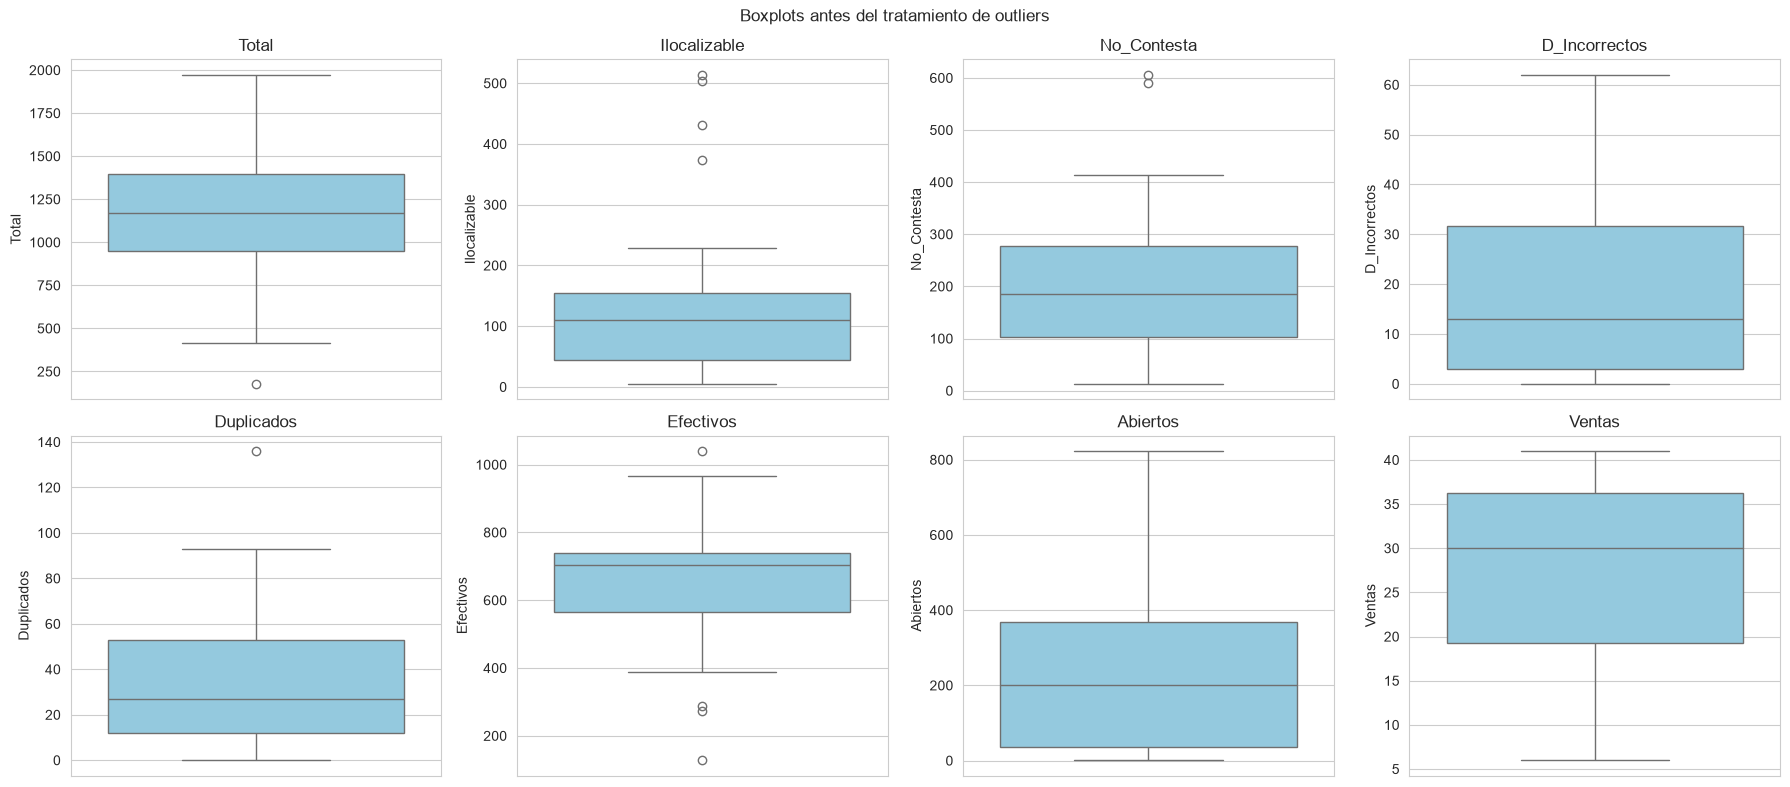

In [19]:
#Columnas numéricas de interés (tipos de Leads + Ventas)
leads_cols = ['Total', 'Ilocalizable', 'No_Contesta', 'D_Incorrectos',
              'Duplicados', 'Efectivos', 'Abiertos', 'Ventas']

#Visualizamos los boxplots antes de tratar los outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), leads_cols):
    sns.boxplot(y=df[col], ax=ax, color='skyblue')
    ax.set_title(col)
plt.suptitle('Boxplots antes del tratamiento de outliers')
plt.tight_layout()
plt.show()

In [20]:
#Función para detectar límites de outliers con el método IQR
def limites_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    return limite_inf, limite_sup

#Reporte de outliers detectados por columna
for col in leads_cols:
    li, ls = limites_iqr(df[col])
    outliers = df[(df[col] < li) | (df[col] > ls)]
    print(f"{col}: {len(outliers)} outlier(s) | límites=({li:.1f}, {ls:.1f})")


Total: 1 outlier(s) | límites=(271.4, 2072.4)
Ilocalizable: 4 outlier(s) | límites=(-120.8, 319.2)
No_Contesta: 2 outlier(s) | límites=(-159.5, 540.5)
D_Incorrectos: 0 outlier(s) | límites=(-40.1, 74.9)
Duplicados: 1 outlier(s) | límites=(-49.5, 114.5)
Efectivos: 4 outlier(s) | límites=(303.0, 999.0)
Abiertos: 0 outlier(s) | límites=(-459.5, 864.5)
Ventas: 0 outlier(s) | límites=(-6.2, 61.8)


In [21]:
#Tratamos los outliers mediante 'capping' (Winsorización):
#los valores fuera de los límites se ajustan al límite más cercano.
#Se eligió este método (en lugar de eliminar filas) porque el dataset es pequeño (28 meses)
#y los valores altos reflejan crecimiento real del negocio, no errores de captura.

df_clean = df.copy()
for col in leads_cols:
    li, ls = limites_iqr(df[col])
    df_clean[col] = df_clean[col].clip(lower=li, upper=ls)

df = df_clean

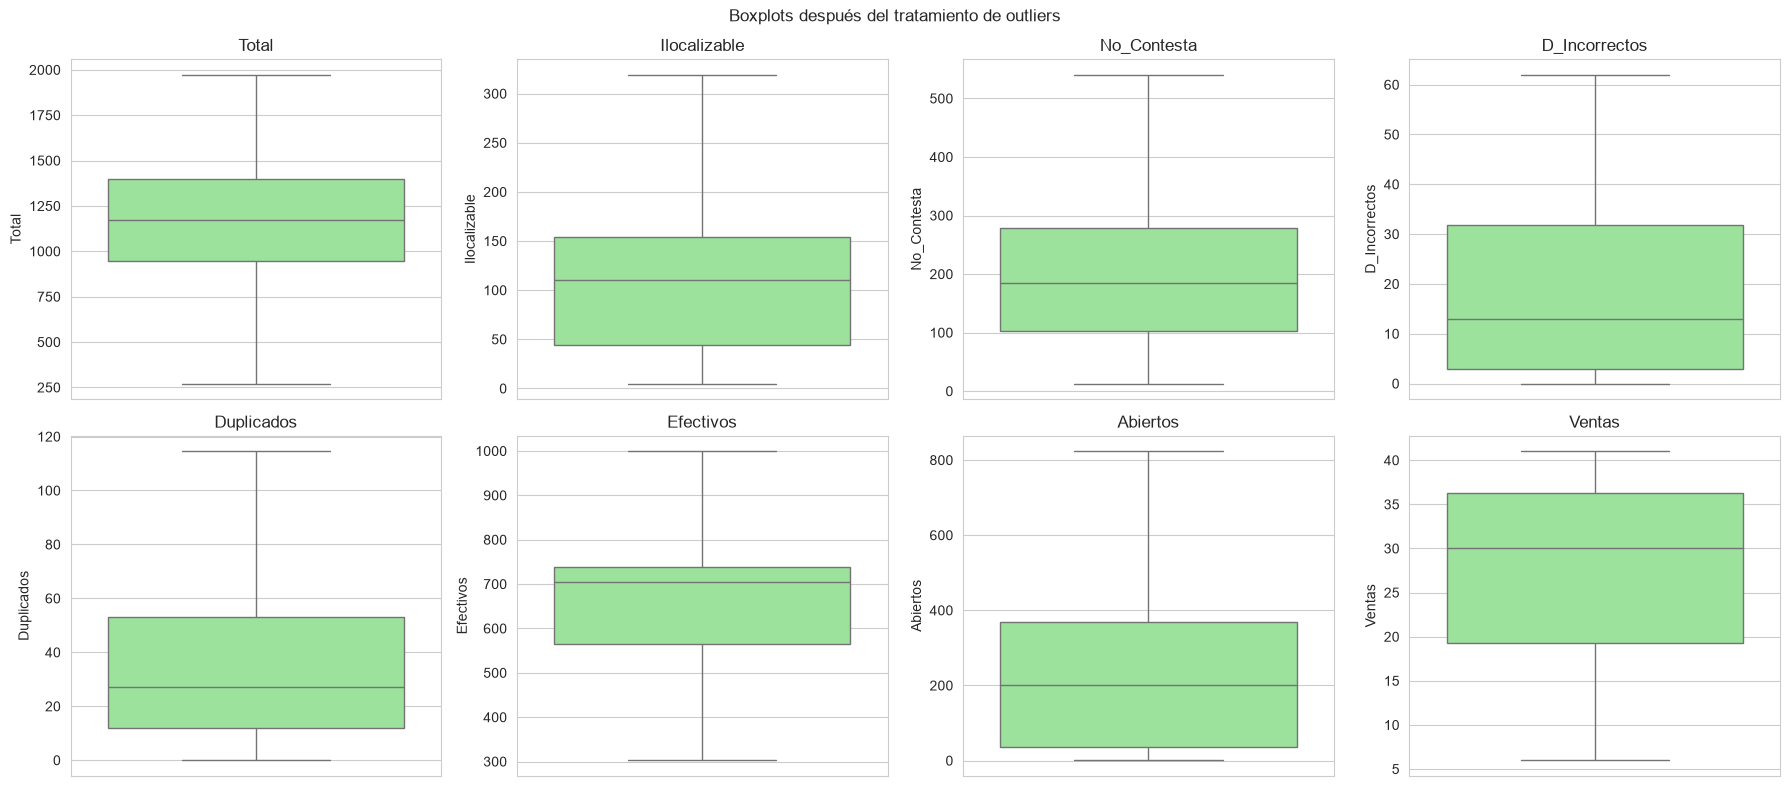

In [22]:
#Visualizamos los boxplots después del tratamiento de outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), leads_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightgreen')
    ax.set_title(col)
plt.suptitle('Boxplots después del tratamiento de outliers')
plt.tight_layout()
plt.show()


Analizar la correlación 